# 📡 Telecom X Parte 2 — Predicción de Churn (Cancelación de Clientes)

**Estructura del notebook:**
1. Carga y exploración inicial
2. Preparación de los datos
3. Correlación y selección de variables
4. Modelado predictivo
5. Interpretación y conclusiones

---
## 1. 📦 Importación de Librerías y Carga de Datos

In [10]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [11]:
# Carga del dataset y normalización

df_raw = pd.read_csv('datos_tratados.csv')

for col in ['customer', 'phone', 'internet', 'account']:
    df_raw[col] = df_raw[col].apply(ast.literal_eval)

df = pd.concat([
    df_raw[['customerID', 'Churn']],
    pd.json_normalize(df_raw['customer']),
    pd.json_normalize(df_raw['phone']),
    pd.json_normalize(df_raw['internet']),
    pd.json_normalize(df_raw['account'])
], axis=1)

# Charges.Total viene como string; se convierte a numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print(f'Forma del dataset: {df.shape}')
df.head(3)

Forma del dataset: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [12]:
# Exploración inicial

print('=== Tipos de datos ===')
print(df.dtypes)
print('\n=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Estadísticas numéricas ===')
df.describe()

=== Tipos de datos ===
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total       float64
dtype: object

=== Valores nulos ===
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV     

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


---
## 2. 🛠️ Preparación de los Datos

In [13]:
# Se eliminan columnas sin valor predictivo

df = df.drop(columns=['customerID'])
print(f'Columnas restantes: {df.shape[1]}')
print(df.columns.tolist())

Columnas restantes: 20
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [14]:
# Se tratan los valores nulos (churn) ya que no suman importancia para el entrenamiento

df = df.dropna(subset=['Churn'])

df = df.assign(Churn=df['Churn'].map({'Yes': 1, 'No': 0}))

median_total = df['Charges.Total'].median()
df = df.assign(**{'Charges.Total': df['Charges.Total'].fillna(median_total)})

print(f'Registros tras limpieza: {len(df)}')
print(f'Nulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Registros tras limpieza: 7043
Nulos restantes:
Series([], dtype: int64)


In [15]:
# Codificación de variables categóricas (One Hot Encoding)

cat_cols = [col for col in df.columns if df[col].dtype == object]
print(f'Columnas categóricas a codificar: {cat_cols}')

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_enc['Churn'] = df_enc['Churn'].astype(int)

print(f'\nDimensiones tras encoding: {df_enc.shape}')
df_enc.head(3)

Columnas categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dimensiones tras encoding: (7043, 31)


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Distribución de clases
  No cancelaron (0):  5174  (73.5%)
  Cancelaron    (1):  1869  (26.5%)


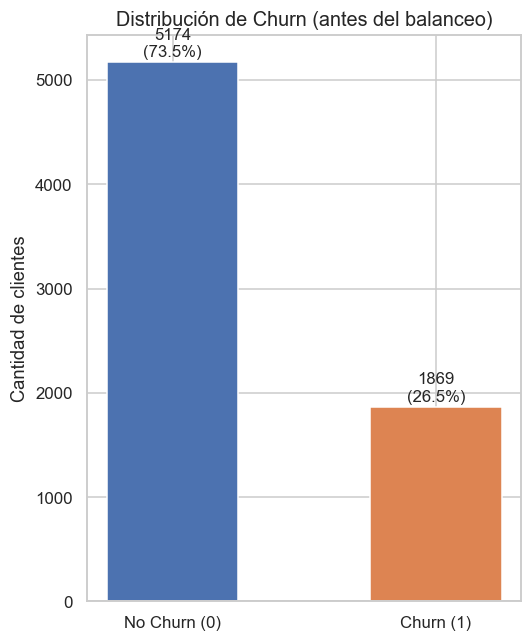


Existe un desbalance moderado (~73% vs ~27%).
Se aplicará oversampling para balancear las clases.


In [18]:
# Análisis de desbalance de clases: Churn como clase minoritaria

conteo  = df_enc['Churn'].value_counts()
porcentaje = df_enc['Churn'].value_counts(normalize=True) * 100

print('Distribución de clases')
print(f'  No cancelaron (0): {conteo[0]:>5}  ({porcentaje[0]:.1f}%)')
print(f'  Cancelaron    (1): {conteo[1]:>5}  ({porcentaje[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 6))
ax.bar(['No Churn (0)', 'Churn (1)'], conteo.values,
       color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(conteo.values, porcentaje.values)):
    ax.text(i, v + 50, f'{v}\n({p:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribución de Churn (antes del balanceo)', fontsize=13)
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

print('\nExiste un desbalance moderado (~73% vs ~27%).')
print('Se aplicará oversampling para balancear las clases.')

In [17]:
# Balanceo de clases. Se usa Oversampling por la cantidad de registros. Se utilizará sklearn.utils.resample

df_majority = df_enc[df_enc['Churn'] == 0]
df_minority = df_enc[df_enc['Churn'] == 1]

df_minority_up = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_up]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print('=== Distribución tras balanceo ===')
print(df_balanced['Churn'].value_counts())
print(f'\nTotal de registros: {len(df_balanced)}')

=== Distribución tras balanceo ===
Churn
1    5174
0    5174
Name: count, dtype: int64

Total de registros: 10348
